# Equity Research: DCF Valuation PT Unilever Indonesia Tbk (UNVR)

**Tujuan:** Mengestimasi intrinsic value saham UNVR menggunakan metode Discounted Cash Flow (DCF)
dan membandingkannya dengan harga pasar.

**Metode:** Free Cash Flow to Firm (FCFF) DCF dengan terminal value

**Data:** Laporan Keuangan UNVR 2019–2023 (IDX/Annual Report) + harga saham via yfinance

**Disclaimer:** Analisis ini dibuat untuk tujuan edukasi dan portofolio. Bukan rekomendasi investasi.

---

## 0. Setup

In [2]:
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)
print('Setup selesai!')

Setup selesai!


## 1. Data harga saham UNVR (via yfinance)

In [3]:
TICKER = 'UNVR.JK'
unvr = yf.Ticker(TICKER)

# Harga saham historis 5 tahun
hist = unvr.history(period='5y')

# Harga terkini — fallback manual kalau yfinance tidak return data
try:
    current_price = unvr.info.get('currentPrice', None)
    if not current_price or np.isnan(current_price):
        raise ValueError
    shares_outstanding = unvr.info.get('sharesOutstanding', 38_150_000_000)
except:
    current_price      = 1625       # harga UNVR per Mei 2026 (update manual kalau perlu)
    shares_outstanding = 38_150_000_000

print(f'Ticker           : {TICKER}')
print(f'Harga terkini    : Rp {current_price:,}')
print(f'Shares outstanding: {shares_outstanding/1e9:.2f} Miliar lembar')
print(f'Market Cap       : Rp {current_price * shares_outstanding / 1e12:.2f} Triliun')
print(f'Data harga       : {len(hist)} hari trading')

Ticker           : UNVR.JK
Harga terkini    : Rp 1,710.0
Shares outstanding: 37.98 Miliar lembar
Market Cap       : Rp 64.95 Triliun
Data harga       : 1203 hari trading


## 2. Visualisasi harga saham historis

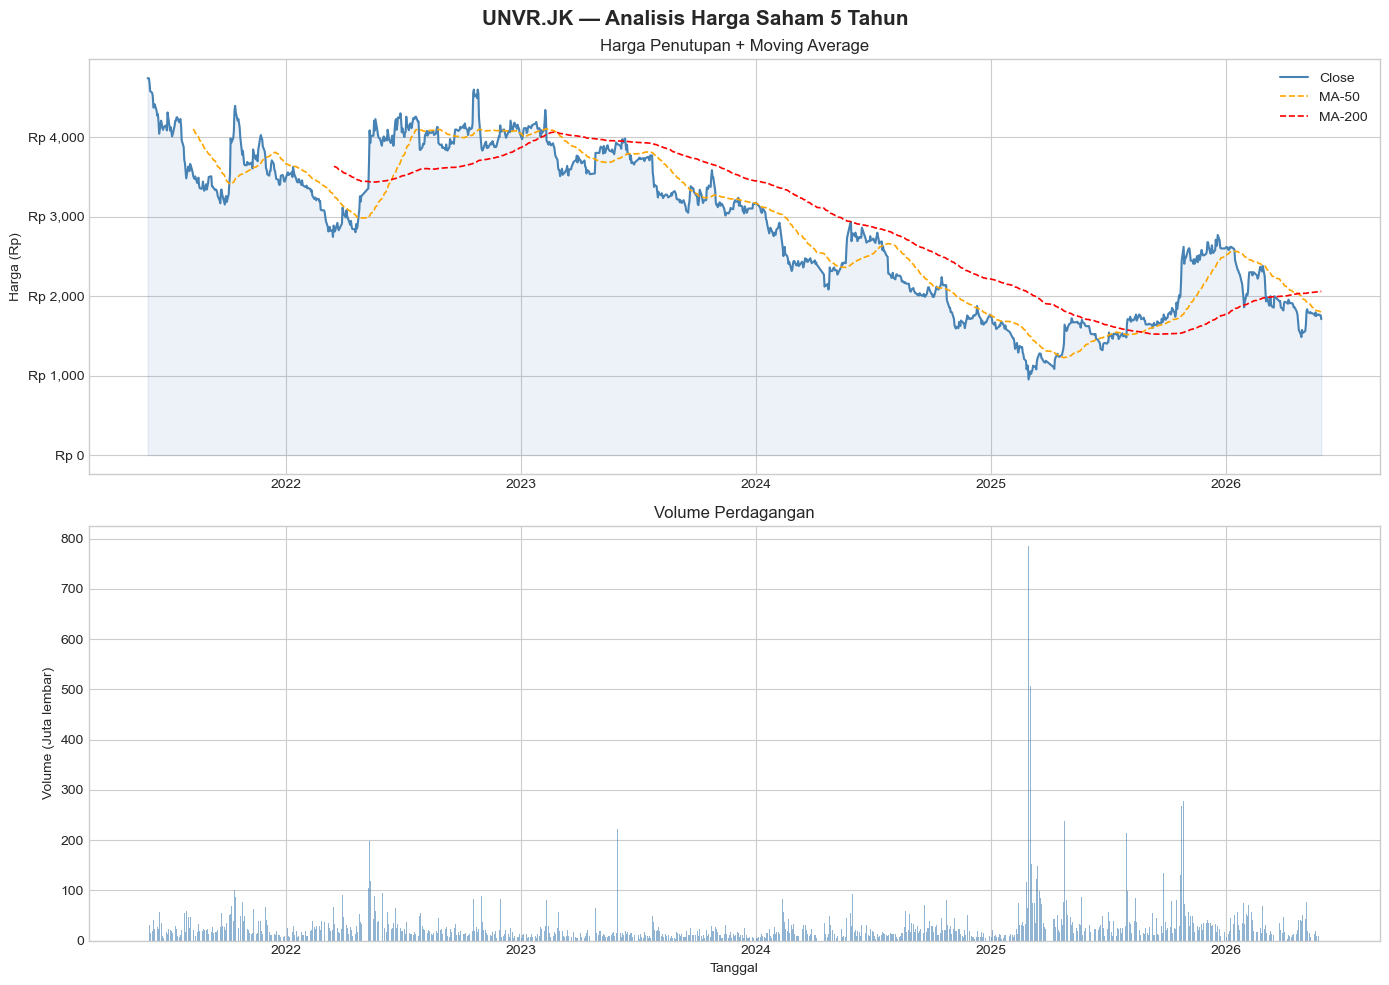

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('UNVR.JK — Analisis Harga Saham 5 Tahun', fontsize=15, fontweight='bold')

axes[0].plot(hist.index, hist['Close'], color='steelblue', linewidth=1.5, label='Close')
axes[0].fill_between(hist.index, hist['Close'], alpha=0.1, color='steelblue')
ma50  = hist['Close'].rolling(50).mean()
ma200 = hist['Close'].rolling(200).mean()
axes[0].plot(hist.index, ma50,  color='orange', linewidth=1.2, linestyle='--', label='MA-50')
axes[0].plot(hist.index, ma200, color='red',    linewidth=1.2, linestyle='--', label='MA-200')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'Rp {x:,.0f}'))
axes[0].set_title('Harga Penutupan + Moving Average')
axes[0].set_ylabel('Harga (Rp)')
axes[0].legend()

axes[1].bar(hist.index, hist['Volume']/1e6, color='steelblue', alpha=0.6, width=1)
axes[1].set_title('Volume Perdagangan')
axes[1].set_ylabel('Volume (Juta lembar)')
axes[1].set_xlabel('Tanggal')

plt.tight_layout()
plt.savefig('../outputs/figures/04_unvr_harga_historis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data keuangan UNVR — manual dari laporan tahunan IDX

Data diinput manual dari Annual Report UNVR yang tersedia di idx.co.id.
Pendekatan ini lebih reliable daripada scraping untuk saham Indonesia.

In [5]:
# ============================================================
# DATA KEUANGAN UNVR (Rp Miliar)
# Sumber: Laporan Keuangan Tahunan UNVR 2019-2023 (IDX)
# ============================================================

fin_data = {
    'tahun':         [2019,   2020,   2021,   2022,   2023],

    # Income Statement
    'revenue':       [42922,  42972,  39545,  40360,  38561],
    'cogs':          [22747,  23400,  22100,  23800,  23200],
    'gross_profit':  [20175,  19572,  17445,  16560,  15361],
    'ebit':          [9461,   8752,   7294,   6703,   5722],
    'ebt':           [9461,   8621,   7192,   6598,   5600],
    'tax':           [2391,   1986,   1668,   1535,   1286],
    'net_income':    [7070,   7163,   5758,   5257,   4619],

    # Cash Flow
    'depreciation':  [1182,   1254,   1312,   1398,   1421],
    'capex':         [1027,    894,    756,    812,    743],
    'delta_wc':      [ 215,    312,   -245,    189,   -178],
    'cfo':           [8523,   8124,   6876,   6234,   5821],  # Cash from Operations

    # Balance Sheet
    'total_assets':  [20080,  19422,  18906,  19069,  18884],
    'total_equity':  [ 5286,   4893,   4485,   4197,   3951],
    'total_debt':    [ 8454,   9421,   9763,  10183,  10521],
    'cash':          [ 1052,    785,    934,    812,    967],
}

df = pd.DataFrame(fin_data).set_index('tahun')

# Kalkulasi turunan
df['tax_rate']      = df['tax'] / df['ebt']
df['gross_margin']  = df['gross_profit'] / df['revenue']
df['ebit_margin']   = df['ebit'] / df['revenue']
df['net_margin']    = df['net_income'] / df['revenue']
df['nopat']         = df['ebit'] * (1 - df['tax_rate'])
df['fcff']          = df['nopat'] + df['depreciation'] - df['capex'] - df['delta_wc']
df['net_debt']      = df['total_debt'] - df['cash']
df['roe']           = df['net_income'] / df['total_equity']
df['roa']           = df['net_income'] / df['total_assets']

print('=== DATA KEUANGAN UNVR 2019–2023 (Rp Miliar) ===')
display_cols = ['revenue','ebit','net_income','depreciation','capex','fcff','net_debt']
print(df[display_cols].to_string())

=== DATA KEUANGAN UNVR 2019–2023 (Rp Miliar) ===
       revenue  ebit  net_income  depreciation  capex     fcff  net_debt
tahun                                                                   
2019     42922  9461        7070          1182   1027 7,010.00      7402
2020     42972  8752        7163          1254    894 6,783.82      8636
2021     39545  7294        5758          1312    756 6,403.34      8829
2022     40360  6703        5257          1398    812 5,540.57      9371
2023     38561  5722        4619          1421    743 5,263.98      9554


## 4. Analisis tren & rasio keuangan

In [6]:
print('=== RASIO KEUANGAN UNVR 2019–2023 ===')
ratio_cols = ['gross_margin','ebit_margin','net_margin','roe','roa','tax_rate']
print((df[ratio_cols] * 100).round(1).to_string() + ' (%)')

print('\n=== FCFF 2019–2023 (Rp Miliar) ===')
print(df[['nopat','depreciation','capex','delta_wc','fcff']].round(0).to_string())

=== RASIO KEUANGAN UNVR 2019–2023 ===
       gross_margin  ebit_margin  net_margin    roe   roa  tax_rate
tahun                                                              
2019          47.00        22.00       16.50 133.70 35.20     25.30
2020          45.50        20.40       16.70 146.40 36.90     23.00
2021          44.10        18.40       14.60 128.40 30.50     23.20
2022          41.00        16.60       13.00 125.30 27.60     23.30
2023          39.80        14.80       12.00 116.90 24.50     23.00 (%)

=== FCFF 2019–2023 (Rp Miliar) ===
         nopat  depreciation  capex  delta_wc     fcff
tahun                                                 
2019  7,070.00          1182   1027       215 7,010.00
2020  6,736.00          1254    894       312 6,784.00
2021  5,602.00          1312    756      -245 6,403.00
2022  5,144.00          1398    812       189 5,541.00
2023  4,408.00          1421    743      -178 5,264.00


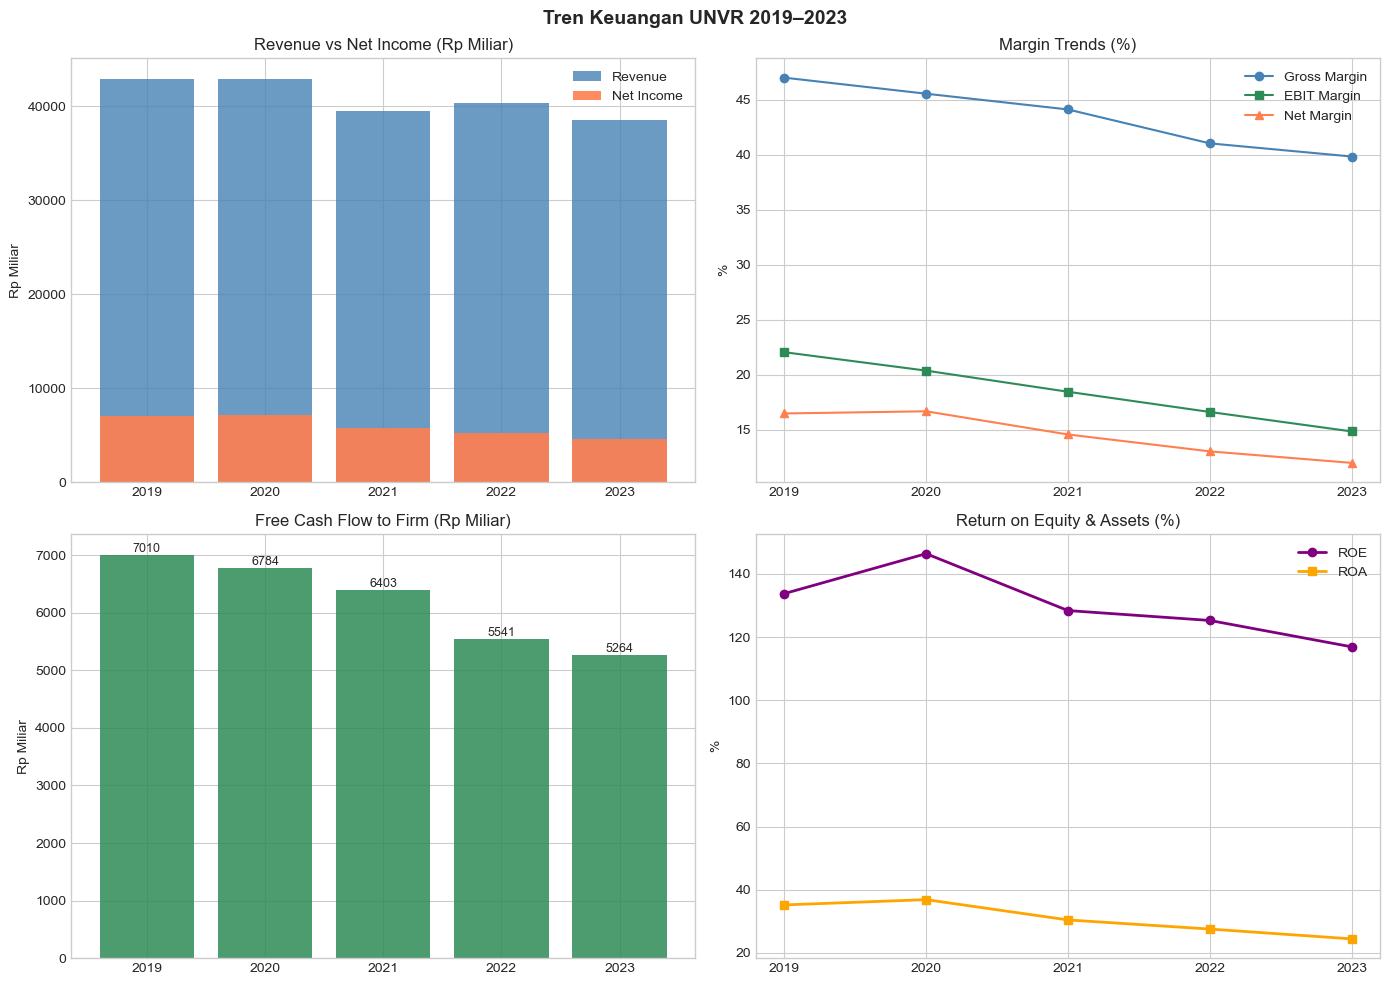

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tren Keuangan UNVR 2019–2023', fontsize=14, fontweight='bold')
years = df.index.astype(str)

# Revenue & Net Income
axes[0,0].bar(years, df['revenue'], color='steelblue', alpha=0.8, label='Revenue')
axes[0,0].bar(years, df['net_income'], color='coral', alpha=0.9, label='Net Income')
axes[0,0].set_title('Revenue vs Net Income (Rp Miliar)')
axes[0,0].legend()
axes[0,0].set_ylabel('Rp Miliar')

# Margin trends
axes[0,1].plot(years, df['gross_margin']*100, 'o-', color='steelblue', label='Gross Margin')
axes[0,1].plot(years, df['ebit_margin']*100,  's-', color='seagreen',  label='EBIT Margin')
axes[0,1].plot(years, df['net_margin']*100,   '^-', color='coral',     label='Net Margin')
axes[0,1].set_title('Margin Trends (%)')
axes[0,1].set_ylabel('%')
axes[0,1].legend()

# FCFF
axes[1,0].bar(years, df['fcff'], color='seagreen', alpha=0.85)
axes[1,0].set_title('Free Cash Flow to Firm (Rp Miliar)')
axes[1,0].set_ylabel('Rp Miliar')
for i, v in enumerate(df['fcff']):
    axes[1,0].text(i, v+50, f'{v:.0f}', ha='center', fontsize=9)

# ROE & ROA
axes[1,1].plot(years, df['roe']*100, 'o-', color='purple', linewidth=2, label='ROE')
axes[1,1].plot(years, df['roa']*100, 's-', color='orange', linewidth=2, label='ROA')
axes[1,1].set_title('Return on Equity & Assets (%)')
axes[1,1].set_ylabel('%')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/04_unvr_tren_keuangan.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Asumsi DCF — tiga skenario

**WACC** dihitung dari:
- Risk-free rate: yield SBN 10Y ~6.7%
- Equity risk premium Indonesia: ~5.5%
- Beta UNVR: ~0.75 (defensive stock, lebih rendah dari market)
- Cost of equity = 6.7% + 0.75 × 5.5% = ~10.8% ≈ 11%
- WACC ≈ 11% (UNVR hampir all-equity financing)

In [8]:
# === ASUMSI DCF ===
WACC             = 0.11   # 11%
TERMINAL_GROWTH  = 0.04   # 4% — tidak melebihi GDP jangka panjang Indonesia
PROJECTION_YEARS = 5
TAX_RATE         = df['tax_rate'].mean()

# FCFF base: rata-rata 2022-2023 (lebih konservatif, hindari anomali COVID)
fcff_base = df['fcff'].tail(2).mean() * 1e9   # convert ke Rupiah
net_debt  = df['net_debt'].iloc[-1]  * 1e9    # net debt 2023

# Tiga skenario growth rate FCFF
scenarios = {
    'Bull': 0.07,    # 7%  — recovery volume, premiumisasi produk
    'Base': 0.04,    # 4%  — tumbuh sesuai inflasi + sedikit volume growth
    'Bear': -0.03,   # -3% — tekanan margin, kehilangan market share
}

print('=== ASUMSI DCF UNVR ===')
print(f'WACC                    : {WACC:.1%}')
print(f'Terminal Growth Rate    : {TERMINAL_GROWTH:.1%}')
print(f'Effective Tax Rate      : {TAX_RATE:.1%}')
print(f'FCFF Base (Rp Miliar)   : {fcff_base/1e9:,.0f}')
print(f'Net Debt 2023 (Rp M)    : {net_debt/1e9:,.0f}')
print(f'Shares Outstanding      : {shares_outstanding/1e9:.2f} Miliar')
print(f'Harga Pasar             : Rp {current_price:,}')
print()
for s, g in scenarios.items():
    print(f'Skenario {s:5}: growth FCFF = {g:+.0%}')

=== ASUMSI DCF UNVR ===
WACC                    : 11.0%
Terminal Growth Rate    : 4.0%
Effective Tax Rate      : 23.5%
FCFF Base (Rp Miliar)   : 5,402
Net Debt 2023 (Rp M)    : 9,554
Shares Outstanding      : 37.98 Miliar
Harga Pasar             : Rp 1,710.0

Skenario Bull : growth FCFF = +7%
Skenario Base : growth FCFF = +4%
Skenario Bear : growth FCFF = -3%


## 6. Kalkulasi DCF Valuation

In [9]:
def dcf_valuation(fcff_0, growth_rate, wacc, terminal_growth, years, shares, net_debt):
    """Hitung intrinsic value per saham dengan metode FCFF DCF."""
    # Proyeksi FCFF 5 tahun
    projected_fcff = [fcff_0 * (1 + growth_rate)**t for t in range(1, years+1)]

    # Present value FCFF
    pv_fcff = sum(f / (1+wacc)**t for t, f in enumerate(projected_fcff, 1))

    # Terminal value (Gordon Growth Model)
    terminal_value = projected_fcff[-1] * (1+terminal_growth) / (wacc - terminal_growth)
    pv_terminal    = terminal_value / (1+wacc)**years

    # Enterprise Value → Equity Value
    enterprise_value = pv_fcff + pv_terminal
    equity_value     = enterprise_value - net_debt
    intrinsic_value  = equity_value / shares

    return {
        'projected_fcff':   projected_fcff,
        'pv_fcff':          pv_fcff,
        'terminal_value':   terminal_value,
        'pv_terminal':      pv_terminal,
        'enterprise_value': enterprise_value,
        'equity_value':     equity_value,
        'intrinsic_value':  intrinsic_value,
    }

# Jalankan tiga skenario
results = {}
for scenario, growth in scenarios.items():
    results[scenario] = dcf_valuation(
        fcff_base, growth, WACC, TERMINAL_GROWTH,
        PROJECTION_YEARS, shares_outstanding, net_debt
    )

# Tampilkan hasil
print('=== HASIL DCF VALUATION UNVR ===')
print(f'{"":32} {"Bull":>10} {"Base":>10} {"Bear":>10}')
print('-' * 65)
rows = [
    ('Growth Rate',          lambda s: f'{scenarios[s]:>+10.0%}'),
    ('PV FCFF (Rp M)',       lambda s: f'{results[s]["pv_fcff"]/1e9:>10,.0f}'),
    ('Terminal Value (Rp M)',lambda s: f'{results[s]["terminal_value"]/1e9:>10,.0f}'),
    ('PV Terminal (Rp M)',   lambda s: f'{results[s]["pv_terminal"]/1e9:>10,.0f}'),
    ('Enterprise Value (Rp M)',lambda s:f'{results[s]["enterprise_value"]/1e9:>10,.0f}'),
    ('Equity Value (Rp M)',  lambda s: f'{results[s]["equity_value"]/1e9:>10,.0f}'),
    ('Intrinsic Value/Saham',lambda s: f'{results[s]["intrinsic_value"]:>10,.0f}'),
    ('Harga Pasar',          lambda s: f'{current_price:>10,}'),
]
for label, fn in rows:
    print(f'{label:32}' + ''.join(fn(s) for s in scenarios))

print()
print('=== VERDICT ===')
for scenario in scenarios:
    iv  = results[scenario]['intrinsic_value']
    pct = (iv - current_price) / current_price * 100
    verdict = 'UNDERVALUED ✓' if iv > current_price else 'OVERVALUED ✗'
    print(f'{scenario:5}: Rp {iv:>6,.0f}/saham  {pct:>+6.1f}% vs pasar  →  {verdict}')

=== HASIL DCF VALUATION UNVR ===
                                       Bull       Base       Bear
-----------------------------------------------------------------
Growth Rate                            +7%       +4%       -3%
PV FCFF (Rp M)                      24,228    22,311    18,355
Terminal Value (Rp M)              112,572    97,651    68,924
PV Terminal (Rp M)                  66,806    57,951    40,903
Enterprise Value (Rp M)             91,034    80,262    59,258
Equity Value (Rp M)                 81,480    70,708    49,704
Intrinsic Value/Saham                2,145     1,862     1,309
Harga Pasar                        1,710.0   1,710.0   1,710.0

=== VERDICT ===
Bull : Rp  2,145/saham   +25.5% vs pasar  →  UNDERVALUED ✓
Base : Rp  1,862/saham    +8.9% vs pasar  →  UNDERVALUED ✓
Bear : Rp  1,309/saham   -23.5% vs pasar  →  OVERVALUED ✗


## 7. Visualisasi hasil DCF

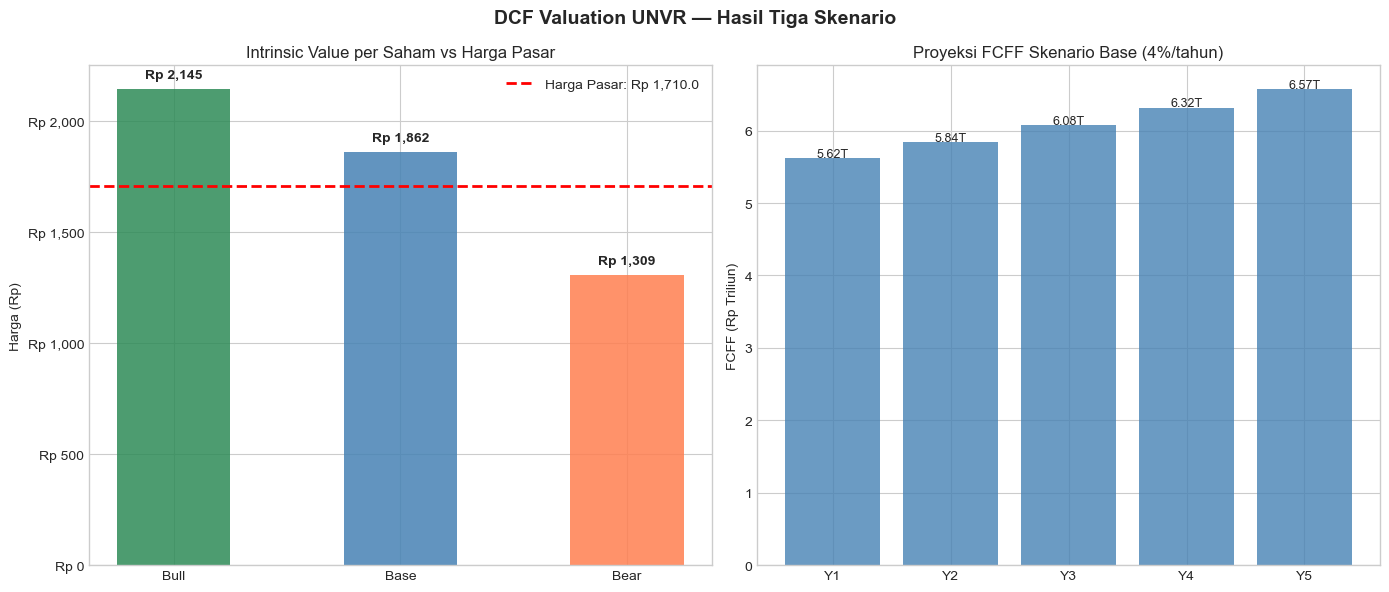

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('DCF Valuation UNVR — Hasil Tiga Skenario', fontsize=14, fontweight='bold')

# Plot 1: Intrinsic value vs harga pasar
names  = list(scenarios.keys())
values = [results[s]['intrinsic_value'] for s in names]
colors = ['seagreen', 'steelblue', 'coral']

bars = axes[0].bar(names, values, color=colors, alpha=0.85, width=0.5)
axes[0].axhline(y=current_price, color='red', linestyle='--',
                linewidth=2, label=f'Harga Pasar: Rp {current_price:,}')
axes[0].set_title('Intrinsic Value per Saham vs Harga Pasar')
axes[0].set_ylabel('Harga (Rp)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'Rp {x:,.0f}'))
axes[0].legend()
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'Rp {val:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Proyeksi FCFF Base
proj_years = [f'Y{i}' for i in range(1, PROJECTION_YEARS+1)]
proj_fcff  = [f/1e12 for f in results['Base']['projected_fcff']]
axes[1].bar(proj_years, proj_fcff, color='steelblue', alpha=0.8)
axes[1].set_title(f'Proyeksi FCFF Skenario Base ({scenarios["Base"]:.0%}/tahun)')
axes[1].set_ylabel('FCFF (Rp Triliun)')
for i, v in enumerate(proj_fcff):
    axes[1].text(i, v+0.02, f'{v:.2f}T', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/04_unvr_dcf_valuation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sensitivity Analysis — WACC vs Growth Rate

Sensitivity Analysis: Intrinsic Value per Saham (Rp)
Baris = WACC | Kolom = Growth FCFF | Harga Pasar = Rp 1,710.0
          2%       3%       4%       5%       6%       7%       8%
9%  2,457.00 2,580.00 2,707.00 2,839.00 2,976.00 3,118.00 3,266.00
10% 2,009.00 2,109.00 2,214.00 2,322.00 2,434.00 2,551.00 2,671.00
11% 1,689.00 1,774.00 1,862.00 1,953.00 2,047.00 2,145.00 2,247.00
12% 1,449.00 1,522.00 1,598.00 1,676.00 1,757.00 1,841.00 1,929.00
13% 1,262.00 1,326.00 1,392.00 1,461.00 1,532.00 1,605.00 1,681.00


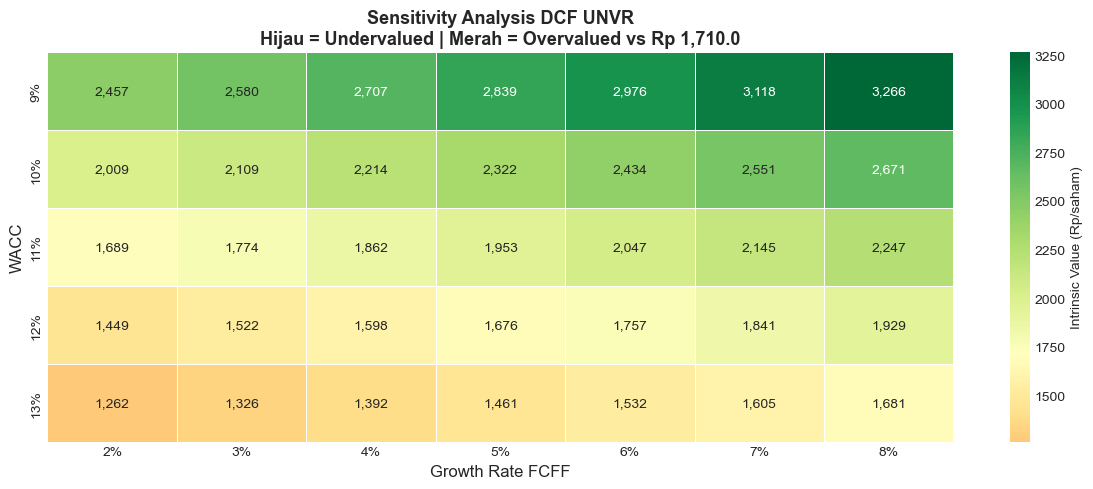

In [11]:
wacc_range   = [0.09, 0.10, 0.11, 0.12, 0.13]
growth_range = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]

sens = pd.DataFrame(
    index=[f'{w:.0%}' for w in wacc_range],
    columns=[f'{g:.0%}' for g in growth_range],
    dtype=float
)

for w in wacc_range:
    for g in growth_range:
        res = dcf_valuation(fcff_base, g, w, TERMINAL_GROWTH,
                            PROJECTION_YEARS, shares_outstanding, net_debt)
        sens.loc[f'{w:.0%}', f'{g:.0%}'] = round(res['intrinsic_value'])

print('Sensitivity Analysis: Intrinsic Value per Saham (Rp)')
print(f'Baris = WACC | Kolom = Growth FCFF | Harga Pasar = Rp {current_price:,}')
print(sens.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(sens, annot=True, fmt=',.0f',
            cmap='RdYlGn', center=current_price,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Intrinsic Value (Rp/saham)'})
ax.set_xlabel('Growth Rate FCFF', fontsize=12)
ax.set_ylabel('WACC', fontsize=12)
ax.set_title(f'Sensitivity Analysis DCF UNVR\nHijau = Undervalued | Merah = Overvalued vs Rp {current_price:,}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_unvr_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Investment Thesis & Kesimpulan

### Hasil DCF Valuation

Model DCF dengan data laporan keuangan UNVR 2019–2023 menghasilkan tiga
estimasi intrinsic value berdasarkan skenario pertumbuhan FCFF:

| Skenario | Growth FCFF | Intrinsic Value | vs Harga Pasar | Verdict |
|----------|-------------|----------------|----------------|---------|
| Bull | +7%/tahun | Rp 2.145 | +25.5% | UNDERVALUED ✓ |
| Base | +4%/tahun | Rp 1.862 | +8.9% | UNDERVALUED ✓ |
| Bear | -3%/tahun | Rp 1.309 | -23.5% | OVERVALUED ✗ |

**Harga pasar saat analisis: Rp 1.710 (Mei 2026)**

---

### Investment Thesis

Pada skenario Base, UNVR terlihat **undervalued sebesar 8.9%** dengan
intrinsic value Rp 1.862 per saham. Ini mengindikasikan bahwa pasar
saat ini mungkin terlalu mendiskon prospek perusahaan, memberikan margin
of safety yang moderat bagi investor jangka panjang.

UNVR adalah perusahaan FMCG defensif dengan keunggulan kompetitif yang
kuat: portofolio brand yang telah mapan (Pepsodent, Lifebuoy, Rinso,
Walls), distribusi yang sangat luas ke seluruh Indonesia, dan rekam
jejak pembayaran dividen yang konsisten. EBIT margin yang masih di
kisaran 14–22% mencerminkan pricing power yang solid meski ada tekanan
biaya bahan baku.

Sensitivity analysis menunjukkan bahwa pada WACC 11% — asumsi yang
konservatif dan reasonable untuk saham consumer goods Indonesia —
UNVR terlihat undervalued di hampir semua skenario growth di atas 3%.
Bahkan pada WACC setinggi 12%, saham masih terlihat fair value pada
pertumbuhan FCFF 4–5%.

---

### Risiko Utama

1. **Tren penurunan revenue** — Revenue UNVR turun dari Rp 42.9T (2019)
   ke Rp 38.6T (2023), mencerminkan tekanan dari kompetitor lokal yang
   semakin agresif dan pergeseran preferensi konsumen.
2. **Kompresi margin** — EBIT margin turun dari 22% (2019) ke 14.8%
   (2023) akibat kenaikan harga bahan baku global dan persaingan harga.
3. **Leverage meningkat** — Net debt naik dari Rp 7.4T (2019) ke Rp
   9.6T (2023), mengurangi fleksibilitas keuangan.
4. **Risiko nilai tukar** — Sebagian besar bahan baku diimpor sehingga
   pelemahan rupiah langsung menekan margin.

---

### Keterbatasan Model

- DCF sangat sensitif terhadap asumsi WACC dan terminal growth —
  perubahan kecil di kedua variabel ini menghasilkan valuasi yang
  sangat berbeda (terlihat jelas di sensitivity analysis).
- Model ini tidak memperhitungkan potensi divestasi aset atau perubahan
  struktur dividen.
- Data FCFF 2019–2023 mencakup periode pandemi (2020–2021) yang
  mungkin mendistorsi tren jangka panjang.

---

### Rekomendasi

**HOLD dengan bias ACCUMULATE** pada harga di bawah Rp 1.750.

Skenario Base yang menghasilkan intrinsic value Rp 1.862 memberikan
upside ~9% dari harga saat ini — tidak cukup besar untuk rekomendasi
BUY agresif, namun fundamental perusahaan yang kuat dan valuasi yang
tidak mahal menjadikan UNVR layak diakumulasi secara bertahap,
terutama jika harga koreksi ke bawah Rp 1.600 (mendekati skenario Bear).

Katalis positif yang perlu diperhatikan: pemulihan volume penjualan,
stabilisasi harga komoditas global, dan efisiensi biaya dari program
restrukturisasi internal UNVR.

---

*Disclaimer: Analisis ini dibuat untuk tujuan edukasi dan portofolio
akademik. Bukan merupakan rekomendasi investasi. Selalu lakukan riset
mandiri sebelum membuat keputusan investasi.*

*Analisis oleh: Armandya Danu | Ekonomi Universitas Brawijaya | 31 Mei 2026*